In [27]:
import sys
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot    as plt
import seaborn              as sns
from sklearn.decomposition  import PCA
from sklearn.manifold       import TSNE
from sklearn.metrics        import silhouette_samples, silhouette_score
from collections            import Counter


import warnings
warnings.filterwarnings('ignore')

# 프로젝트 경로 설정
project_root = 'c:/big20/git/big20-ML-project2-team3/OpionReview'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from utils.preprocessing import get_default_data

# PyCaret 임포트
from pycaret.clustering import *
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances, manhattan_distances


class PyCaretAPAnalyzer(PyCaretAPAnalyzer):
    """
    PyCaret 기반 Affinity Propagation 분석기 (수정/개선 버전)
    - sklearn 탐색 후 PyCaret 모델로 생성 -> plot_model/assign_model과 호환
    - affinity = ['cosine','euclidean','manhattan'] 비교/튜닝 지원
    """

    def __init__(self):
        self.document_df = None
        self.tfidf_matrix = None
        self.setup_result = None
        self.models = {}        # {'euclidean': pycaret_model, ...}
        self.best_model = None  # pycaret model (create_model로 생성된 것)
        self.best_method = None

    def load_data(self):
        print("="*80)
        print("📂 데이터 로딩 중...")
        print("="*80)

        self.document_df = get_default_data()

        print(f"✅ 데이터 로드 완료")
        print(f"   - 문서 수: {len(self.document_df)}")
        print(f"   - 컬럼: {list(self.document_df.columns)}")
        print("="*80 + "\n")

        return self.document_df

    def setup_pycaret(self, normalize=True, pca=False, pca_components=None):
        print("="*80)
        print("🔧 PyCaret 클러스터링 환경 설정 중...")
        print("="*80 + "\n")

        numeric_cols = self.document_df.select_dtypes(include=[np.number]).columns.tolist()

        if not numeric_cols:
            raise ValueError("숫자형 피처가 없습니다. TF-IDF 변환이 제대로 되었는지 확인하세요.")

        print(f"📊 사용할 피처 수: {len(numeric_cols)}")

        self.setup_result = setup(
            data=self.document_df[numeric_cols],
            normalize=normalize,
            pca=pca,
            pca_components=pca_components,
            session_id=23,
            verbose=False,
            html=False
        )

        print("✅ PyCaret 설정 완료\n")

        return self.setup_result

    # ------------ 유틸 함수 ------------
    @staticmethod
    def _normalize_labels_for_metrics(labels):
        """
        labels가 비연속적(예: [0, 73, 8, 73, ...])일 때
        silhouette 등에서 사용하는 0..K-1 형태로 재매핑
        """
        unique_labels = np.unique(labels)
        # 제거할 노이즈 라벨이 있다면(예:-1) 제거해서 카운트 (AP은 보통 -1 없음)
        unique_labels = sorted([u for u in unique_labels if u != -1])
        if len(unique_labels) == 0:
            return labels, 0
        label_map = {old: new for new, old in enumerate(unique_labels)}
        normalized = np.array([label_map[l] if l in label_map else -1 for l in labels])
        n_clusters = len(unique_labels)
        return normalized, n_clusters

    # ------------ 튜닝 함수 (기존 tune_ap_model 개선) ------------
    def tune_ap_model(self, method='euclidean', target_clusters=20,
                    damping_range=(0.5, 0.95), preference_percentiles=[10, 20, 30, 40, 50]):
        """
        한 방식(method)에 대해 Affinity Propagation 튜닝.
        method: 'euclidean' | 'cosine' | 'manhattan'
        반환: (best_pycaret_model, results_df)
        """
        print("="*80)
        print(f"🔍 AP 모델 튜닝 중 (method={method}, 목표 군집 수: {target_clusters})")
        print("="*80 + "\n")

        if self.setup_result is None:
            raise ValueError("먼저 setup_pycaret()을 실행하세요.")

        X = get_config('X')  # PyCaret 내부 전처리된 X (numpy array / DataFrame)
        # ensure numpy array
        if hasattr(X, 'toarray'):
            X_arr = X.toarray()
        else:
            X_arr = np.asarray(X)

        # similarity matrix (for precomputed affinity) or None for euclidean
        if method == 'euclidean':
            similarity_matrix = None
            # preference candidates from -euclidean distances distribution
            tmp = -euclidean_distances(X_arr)
            pref_candidates = [np.percentile(tmp, p) for p in preference_percentiles]
            # include None as option (let AP default) as well
            pref_candidates = [None] + pref_candidates
        elif method == 'cosine':
            tmp = cosine_similarity(X_arr)
            pref_candidates = [np.percentile(tmp, p) for p in preference_percentiles]
            similarity_matrix = tmp
        elif method == 'manhattan':
            tmp = -manhattan_distances(X_arr)
            pref_candidates = [np.percentile(tmp, p) for p in preference_percentiles]
            similarity_matrix = tmp
        else:
            raise ValueError("method must be one of 'euclidean','cosine','manhattan'")

        results = []
        from sklearn.cluster import AffinityPropagation
        from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

        print("파라미터 조합별 군집 수 테스트:")
        print("-" * 80)

        for damping in np.linspace(damping_range[0], damping_range[1], 5):
            for pref in pref_candidates:
                try:
                    # sklearn AP 설정
                    if method == 'euclidean':
                        ap = AffinityPropagation(
                            damping=float(damping),
                            preference=pref,
                            affinity='euclidean',
                            max_iter=500,
                            random_state=23
                        )
                        ap.fit(X_arr)
                    else:
                        ap = AffinityPropagation(
                            damping=float(damping),
                            preference=pref,
                            affinity='precomputed',
                            max_iter=500,
                            random_state=23
                        )
                        ap.fit(similarity_matrix)

                    labels = ap.labels_
                    normalized_labels, n_clusters = self._normalize_labels_for_metrics(labels)

                    # metric 계산
                    if n_clusters > 1:
                        # silhouette expects label integers and original features X_arr
                        silhouette = silhouette_score(X_arr, normalized_labels)
                        calinski = calinski_harabasz_score(X_arr, normalized_labels)
                        davies = davies_bouldin_score(X_arr, normalized_labels)
                    else:
                        silhouette = 0.0
                        calinski = 0.0
                        davies = np.nan

                    diff = abs(n_clusters - target_clusters)

                    results.append({
                        'method': method,
                        'damping': float(damping),
                        'preference': None if pref is None else float(pref),
                        'n_clusters': int(n_clusters),
                        'silhouette': float(silhouette),
                        'calinski': float(calinski),
                        'davies': float(davies),
                        'diff_from_target': int(diff)
                    })

                    status = "✅" if diff <= 5 else "⚠️"
                    print(f"{status} Damping: {damping:.2f}, Pref: {str(pref):8s} → "
                        f"군집: {n_clusters:3d}, Silhouette: {silhouette:.4f}")

                except Exception as e:
                    print(f"❌ Damping: {damping:.2f}, Pref: {str(pref):8s} → 실패: {e}")

        # 안전한 정렬: 컬럼 존재하는지 확인
        if len(results) > 0:
            results_df = pd.DataFrame(results)
            sort_cols = []
            if 'diff_from_target' in results_df.columns:
                sort_cols.append('diff_from_target')
            # 'silhouette' 컬럼이 있는 경우 내림차순으로 정렬(클러스터 수 차이 우선, silhouette 두번째)
            if 'silhouette' in results_df.columns:
                sort_cols.append('silhouette')

            if sort_cols:
                # diff는 오름차순, silhouette은 내림차순
                ascending = [True] + [False] * (len(sort_cols) - 1)
                results_df = results_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
            else:
                results_df = results_df.reset_index(drop=True)
        else:
            results_df = pd.DataFrame(results)

        if results_df.empty:
            print("튜닝 결과가 없습니다.")
            return None, results_df

        # 최적 결과 선택: diff 우선, 그 다음 silhouette
        best_idx = results_df['diff_from_target'].idxmin()
        best_row = results_df.loc[best_idx]

        print("\n" + "="*80)
        print("🏆 최적 파라미터 (sklearn 탐색 결과)")
        print("="*80)
        print(f"  Method: {best_row['method']}")
        print(f"  Damping: {best_row['damping']:.3f}")
        print(f"  Preference: {best_row['preference']}")
        print(f"  군집 수: {int(best_row['n_clusters'])}")
        print(f"  Silhouette Score: {best_row['silhouette']:.4f}")
        print("="*80 + "\n")

        # PyCaret create_model로 동일 파라미터 모델 생성(시각화/assign_model 호환용)
        # Note: create_model's preference expects None or numeric
        # 안전하게 None/float 처리
        pref_val = best_row['preference']
        pycaret_pref = None if pd.isna(pref_val) else pref_val
        pycaret_model = create_model('ap', damping=best_row['damping'], preference=pycaret_pref, verbose=False)

        # 저장
        self.models[method] = pycaret_model
        self.best_model = pycaret_model
        self.best_method = method

        return pycaret_model, results_df


    # ------------ 비교 함수 (개선된 compare_methods / compare_all_similarity_methods 통합) ------------
    def compare_all_similarity_methods(self, target_clusters=20,
                                       damping_range=(0.6, 0.95),
                                       preference_percentiles=[10, 20, 30, 40, 50]):
        """
        cosine / euclidean / manhattan 방식 모두 튜닝하여 비교한 뒤
        PyCaret 모델(create_model로 생성된 것) 형태로 best_model 저장.
        """
        methods = ['euclidean', 'cosine', 'manhattan']
        all_summaries = []

        for m in methods:
            print("\n" + "#" * 80)
            print(f"▶ 튜닝 시작: {m}")
            print("#" * 80 + "\n")
            model, res_df = self.tune_ap_model(method=m, target_clusters=target_clusters,
                                              damping_range=damping_range,
                                              preference_percentiles=preference_percentiles)
            if res_df is not None and not res_df.empty:
                # best row for this method (smallest diff)
                best_for_method = res_df.sort_values(['diff_from_target','silhouette'], ascending=[True, False]).iloc[0]
                all_summaries.append({
                    'Method': m,
                    'Clusters': int(best_for_method['n_clusters']),
                    'Damping': float(best_for_method['damping']),
                    'Preference': best_for_method['preference'],
                    'Silhouette': float(best_for_method['silhouette']),
                    'Calinski': float(best_for_method['calinski']),
                    'Davies': float(best_for_method['davies'])
                })

        summary_df = pd.DataFrame(all_summaries)
        if summary_df.empty:
            print("모든 방식에 대한 결과가 없습니다.")
            return None, summary_df

        print("\n" + "="*80)
        print("📊 방식별 최적 결과 요약")
        print("="*80 + "\n")
        print(summary_df.reset_index(drop=True))

        # silhouette로 최고 방법 선택 (동일하면 clusters 기준)
        best_idx = summary_df['Silhouette'].idxmax()
        best_method = summary_df.loc[best_idx, 'Method']

        print("\n\n🏆 최종 Best Method:", best_method.upper())
        print(f"   Silhouette Score = {summary_df.loc[best_idx, 'Silhouette']:.4f}")
        print("="*80 + "\n")

        # best PyCaret 모델을 self.best_model으로 유지 (self.tune_ap_model에서 저장됨)
        self.best_method = best_method
        self.best_model = self.models.get(best_method, None)

        return self.best_model, summary_df

    # ------------ 시각화  ------------
    def visualize_ap_1d(self, model=None, save_dir='../images'):
        """
        1차원 TF-IDF/feature 기반 AP 결과 시각화
        - Scatter plot: 샘플별 cluster label
        - Bar plot: cluster별 샘플 수
        """
        if model is None:
            model = self.best_model
        if model is None:
            raise ValueError("시각화할 모델이 없습니다. 먼저 모델을 생성하세요.")

        # assign clusters
        df = self.assign_clusters(model)
        # Cluster 컬럼을 숫자로 변환 ('Cluster 0' -> 0)
        labels = df['Cluster'].astype(str).str.replace('Cluster ', '').astype(int).values

        # Scatter plot (1D)
        plt.figure(figsize=(10, 2))
        plt.scatter(np.arange(len(labels)), np.zeros_like(labels), c=labels, cmap='tab20', s=50)
        plt.yticks([])
        plt.xlabel("Sample index")
        plt.title("AP Cluster Assignment (1D)")
        plt.tight_layout()
        plt.show()

        # Cluster distribution bar plot
        cluster_counts = Counter(labels)
        plt.figure(figsize=(10, 4))
        plt.bar(cluster_counts.keys(), cluster_counts.values(), color='tab20')
        plt.xlabel("Cluster")
        plt.ylabel("Number of documents")
        plt.title("Cluster Size Distribution")
        plt.tight_layout()
        plt.show()

        print(f"✅ 1D 시각화 완료. 총 {len(cluster_counts)}개 cluster 존재")




    # ------------ assign / save remain unchanged but compatible ------------
    def assign_clusters(self, model=None):
        if model is None:
            model = self.best_model

        if model is None:
            raise ValueError("모델이 없습니다. 먼저 모델을 생성하세요.")

        result_df = assign_model(model)
        result_df = pd.concat([self.document_df, result_df[['Cluster']]], axis=1)

        print("\n📊 군집 분포:")
        print("-" * 60)

        cluster_counts = result_df['Cluster'].value_counts().sort_index()

        for cluster_id, count in cluster_counts.head(20).items():
            percentage = (count / len(result_df)) * 100
            bar = '█' * int(percentage / 2)
            print(f"  군집 {str(cluster_id):3s}: {count:4d}개 ({percentage:5.1f}%) {bar}")

        if len(cluster_counts) > 20:
            remaining = cluster_counts.iloc[20:].sum()
            print(f"  ... 외 {len(cluster_counts)-20}개 군집: {remaining}개")

        print()
        return result_df

    def save_model_pycaret(self, model=None, model_name='ap_model'):
        if model is None:
            model = self.best_model

        if model is None:
            raise ValueError("저장할 모델이 없습니다.")

        save_model(model, model_name)
        print(f"💾 모델 저장 완료: {model_name}.pkl")


In [28]:
# 실행
analyzer = PyCaretAPAnalyzer()
analyzer.load_data()
analyzer.setup_pycaret(normalize=True, pca=False)


📂 데이터 로딩 중...
📂 51개 파일 발견
🔄 텍스트 전처리 시작...
   옵션: HTML제거=True, URL제거=True, 숫자제거=True
   옵션: 불용어제거=True, Lemmatization=True, Stemming=False
✅ 전처리 완료:
   - 원본 문서 수: 51
   - 제거된 빈 문서: 0
   - 최종 문서 수: 51
   - 평균 단어 수: 1266.9
✅ 데이터 로드 완료
   - 문서 수: 51
   - 컬럼: ['filename', 'opinion_text', 'processed_text', 'word_count']

🔧 PyCaret 클러스터링 환경 설정 중...

📊 사용할 피처 수: 1
✅ PyCaret 설정 완료



In [29]:
# 모든 방식 비교/튜닝
best_model, summary = analyzer.compare_all_similarity_methods(target_clusters=20)


################################################################################
▶ 튜닝 시작: euclidean
################################################################################

🔍 AP 모델 튜닝 중 (method=euclidean, 목표 군집 수: 20)

파라미터 조합별 군집 수 테스트:
--------------------------------------------------------------------------------
⚠️ Damping: 0.60, Pref: None     → 군집:   7, Silhouette: 0.6017
✅ Damping: 0.60, Pref: -2193.0  → 군집:  24, Silhouette: 0.6021
⚠️ Damping: 0.60, Pref: -1293.0  → 군집:  27, Silhouette: 0.5611
⚠️ Damping: 0.60, Pref: -890.0   → 군집:  26, Silhouette: 0.5493
⚠️ Damping: 0.60, Pref: -666.0   → 군집:  26, Silhouette: 0.5493
⚠️ Damping: 0.60, Pref: -485.0   → 군집:  29, Silhouette: 0.5188
⚠️ Damping: 0.69, Pref: None     → 군집:   7, Silhouette: 0.6017
✅ Damping: 0.69, Pref: -2193.0  → 군집:  24, Silhouette: 0.6021
⚠️ Damping: 0.69, Pref: -1293.0  → 군집:  27, Silhouette: 0.5611
⚠️ Damping: 0.69, Pref: -890.0   → 군집:  28, Silhouette: 0.5400
⚠️ Damping: 0.69, Pref: -666.0   → 군집:  28,


📊 군집 분포:
------------------------------------------------------------
  군집 Cluster 0:   51개 (100.0%) ██████████████████████████████████████████████████



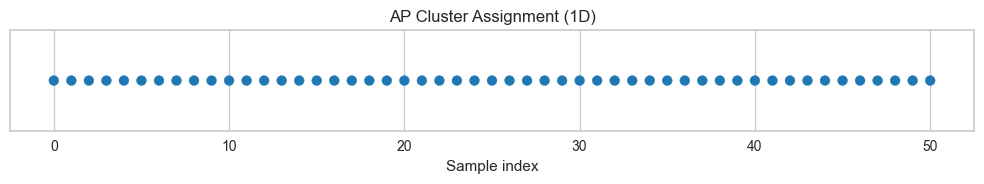

ValueError: 'tab20' is not a valid color value.

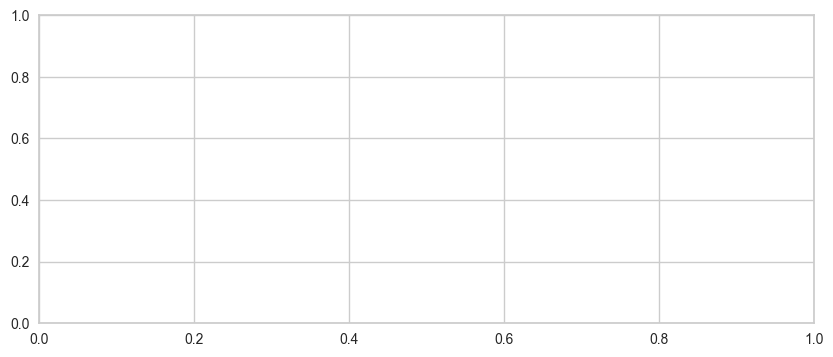

In [ ]:
analyzer.visualize_ap_1d(best_model)
# 포기... ㅠ.ㅜ

In [ ]:
# 군집 할당
df_with_clusters = analyzer.assign_clusters(best_model)